# Psar: E-Commerce Inquiry Intelligence

**Psar** (ផ្សារ, meaning "market" in Khmer) is a structured product query system for Cambodian social online shopping.

The full structure of this project will consist of: 
1. Customer query
2. TF-IDF vectorization
3. Logistic regression / catBoost intent classification
4. Rule-based entity extraction
5. SentenceTransformer embeddings 
6. Cosine similarity product retrieval
7. Inventory stock check
8. Template-grounded answer generation
10. Purchase and real-time inventory update



In [1]:
import pandas as pd
import numpy as np
import json
import random
from datetime import datetime

# Set seeds
random.seed(42)
np.random.seed(42)

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# Load catalog
catalog_df = pd.read_csv('../data/psar_catalog.csv')

# Load queries
queries_df = pd.read_csv('../data/psar_queries.csv')

print(catalog_df.head())

queries_df.describe()

  product_id     name  color  category  price  available_sizes  stock_XS  \
0     C_P001  T-Shirt   Blue  Clothing  55.48  XS,S,M,L,XL,XXL      20.0   
1     C_P002  T-Shirt    Red  Clothing  55.48  XS,S,M,L,XL,XXL       9.0   
2     C_P003  T-Shirt  White  Clothing  55.48  XS,S,M,L,XL,XXL      12.0   
3     C_P004  T-Shirt  Black  Clothing  55.48  XS,S,M,L,XL,XXL      17.0   
4     C_P005  T-Shirt  Green  Clothing  55.48  XS,S,M,L,XL,XXL       9.0   

   stock_S  stock_M  stock_L  ...  stock_5  stock_6  stock_7  stock_8  \
0     12.0     23.0     22.0  ...      NaN      NaN      NaN      NaN   
1     25.0      5.0      4.0  ...      NaN      NaN      NaN      NaN   
2      5.0     10.0      6.0  ...      NaN      NaN      NaN      NaN   
3     23.0     14.0      8.0  ...      NaN      NaN      NaN      NaN   
4     24.0     11.0     25.0  ...      NaN      NaN      NaN      NaN   

   stock_9  stock_10  stock_11  stock_12  stock_13  stock_One_Size  
0      NaN       NaN       NaN     

,query,intent
count,360,360
unique,170,6
top,What products are available?,size_question
freq,18,60


In [4]:
# Convert catalog CSV to product objects
products = []

for x, row in catalog_df.iterrows():
    if pd.notna(row["available_sizes"]):
        available_sizes = [size.strip() for size in str(row["available_sizes"]).split(",")]
    else:
        available_sizes = []

    stock_by_size = {}

    for size in available_sizes:
        stock_col = f"stock_{size}".replace(" ", "_")
        if stock_col in catalog_df.columns:
            stock_value = row[stock_col]
            if pd.notna(stock_value):
                stock_by_size[size] = int(stock_value)
            else:
                stock_by_size[size] = 0
        else:
            stock_by_size[size] = 0

    product = {"product_id": str(row["product_id"]),
               "name": str(row["name"]),
               "color": str(row["color"]),
               "category": str(row["category"]),
               "price": float(row["price"]),
               "available_sizes": available_sizes,
               "stock_by_size": stock_by_size}
    products.append(product)

products[1]

{'product_id': 'C_P002',
 'name': 'T-Shirt',
 'color': 'Red',
 'category': 'Clothing',
 'price': 55.48,
 'available_sizes': ['XS', 'S', 'M', 'L', 'XL', 'XXL'],
 'stock_by_size': {'XS': 9, 'S': 25, 'M': 5, 'L': 4, 'XL': 24, 'XXL': 10}}

In [5]:
# Creates a live inventory object to use for retrieval and purchase pipeline 
class Inventory:
    def __init__(self, products):
        self.products = products
        self.inventory = {}
        self.transactions = []

        for product in products:
            product_id = str(product["product_id"])
            self.inventory[product_id] = {
                str(size): int(qty) for size, qty in product.get("stock_by_size", {}).items()}

    def get_product(self, product_id):
        product_id = str(product_id)
        for product in self.products:
            if str(product["product_id"]) == product_id:
                return product
        return None

    def check_stock(self, product_id, size):
        product_id = str(product_id)
        size = str(size)
        if product_id not in self.inventory:
            return 0
        return int(self.inventory[product_id].get(size, 0))

    def get_all_stock(self, product_id):
        product_id = str(product_id)
        return self.inventory.get(product_id, {}).copy()

    def buy_product(self, product_id, size, quantity=1):
        product_id = str(product_id)
        size = str(size)
        quantity = int(quantity)

        product = self.get_product(product_id)

        if product is None:
            return {
                "success": False,
                "message": "Product not found.",
                "stock_before": None,
                "stock_after": None,
                "transaction": None,}

        if quantity <= 0:
            return {
                "success": False,
                "message": "Quantity must be at least 1.",
                "stock_before": None,
                "stock_after": None,
                "transaction": None,}

        current_stock = self.check_stock(product_id, size)

        if current_stock < quantity:
            return {
                "success": False,
                "message": f"Not enough stock. Only {current_stock} available in size {size}.",
                "stock_before": current_stock,
                "stock_after": current_stock,
                "transaction": None,}

        stock_before = current_stock
        self.inventory[product_id][size] = current_stock - quantity
        stock_after = self.inventory[product_id][size]

        transaction = {
            "transaction_id": f"TXN-{len(self.transactions)+1:04d}",
            "time": datetime.now().isoformat(timespec="seconds"),
            "product_id": product_id,
            "name": product["name"],
            "color": product["color"],
            "category": product["category"],
            "size": size,
            "quantity": quantity,
            "price": float(product["price"]),
            "total_price": round(float(product["price"]) * quantity, 2),
            "stock_before": stock_before,
            "stock_after": stock_after,
        }
        self.transactions.append(transaction)

        return {
            "success": True,
            "message": (
                f"Purchased {quantity}x {product['color']} {product['name']} "
                f"(size {size}) for ${transaction['total_price']:.2f}."
            ),
            "stock_before": stock_before,
            "stock_after": stock_after,
            "transaction": transaction,}


inventory = Inventory(products)

print(f"Inventory has {len(inventory.inventory)} products.")
print(f"Test: stock check:  {products[0]['product_id']} in size {products[0]['available_sizes'][0]}: "
    f"{inventory.check_stock(products[0]['product_id'], products[0]['available_sizes'][0])}")

Inventory has 300 products.
Test: stock check:  C_P001 in size XS: 20


In [6]:
#Train-test split 

custom_stop_words = ["do", "you", "have", "what", "is", "it", "are", "can", "i", "the", "a", "an", "in", "for", "of", "to", "me", 
                     "how", "this", "products", "your", "get", "items"]

X_train_text, X_test_text, y_train, y_test = train_test_split( queries_df['query'], queries_df['intent'],
    test_size=0.3, random_state=42, stratify=queries_df['intent'])

vec = TfidfVectorizer(max_features=300, ngram_range=(1, 2), min_df=2, max_df=0.95, stop_words=custom_stop_words)

X_train = vec.fit_transform(X_train_text)
X_test  = vec.transform(X_test_text)
print(f"Train: {X_train.shape[0]}")
print(f"Test: {X_test.shape[0]}")


X_all = vec.transform(queries_df["query"])

tfidf_df = pd.DataFrame({"term": vec.get_feature_names_out(), "score": X_all.sum(axis=0).A1
}).sort_values("score", ascending=False)

print(tfidf_df.head(2))

Train: 252
Test: 108
          term      score
102      stock  29.609643
10   available  28.145603


In [7]:
#Logistic regression
logistic = LogisticRegression(max_iter=100, random_state=42)

logistic.fit(X_train, y_train)

y_pred = logistic.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9815

Classification Report:
                       precision    recall  f1-score   support

   availability_check       1.00      0.94      0.97        18
complex_multicriteria       1.00      1.00      1.00        18
                other       1.00      1.00      1.00        18
        price_inquiry       1.00      1.00      1.00        18
       product_search       0.90      1.00      0.95        18
        size_question       1.00      0.94      0.97        18

             accuracy                           0.98       108
            macro avg       0.98      0.98      0.98       108
         weighted avg       0.98      0.98      0.98       108



In [8]:
cat = CatBoostClassifier(iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    random_seed=42,
    verbose=False)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

y_pred_cat = y_pred_cat.flatten()

cat_accuracy = accuracy_score(y_test, y_pred_cat)
print(cat_accuracy)
print(classification_report(y_test, y_pred_cat))



0.9907407407407407
                       precision    recall  f1-score   support

   availability_check       1.00      1.00      1.00        18
complex_multicriteria       1.00      1.00      1.00        18
                other       1.00      1.00      1.00        18
        price_inquiry       1.00      1.00      1.00        18
       product_search       0.95      1.00      0.97        18
        size_question       1.00      0.94      0.97        18

             accuracy                           0.99       108
            macro avg       0.99      0.99      0.99       108
         weighted avg       0.99      0.99      0.99       108



In [9]:
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"CatBoost Accuracy: {cat_accuracy:.4f}") 

Logistic Regression Accuracy: 0.9815
CatBoost Accuracy: 0.9907


In [10]:
#Test with queries 
test_queries = [
    "Do you have any dress left?",
    "Is the dress available in size M?",
    "How much is the polar shirt?"]

test_X = vec.transform(test_queries)

cat_preds = cat.predict(test_X).flatten()

for query, pred in zip(test_queries, cat_preds):
    print(f"Query: {query}")
    print(f"Predicted intent: {pred}")
    print()

Query: Do you have any dress left?
Predicted intent: product_search

Query: Is the dress available in size M?
Predicted intent: size_question

Query: How much is the polar shirt?
Predicted intent: price_inquiry



## Build in: Intent Classification
This helper wraps them into a single classification function. CatBoost is the default. Logistic Regression is kept as a transparent baseline for the paper's model comparison

In [11]:
#classifies the user's query into an intent category
#query is converted into a numerical feature vector 

def classify_intent(query, model_choice="catboost"):
    query_vec = vec.transform([query])

    if model_choice == "catboost":
        try:
            # predict the intent
            pred = cat.predict(query_vec)

            # Flatten the prediction output 
            pred = np.array(pred).flatten()[0]

            return str(pred)

        except Exception as e:
            print(f"CatBoost prediction failed ({e}), falling back to Logistic Regression")
            return str(logistic.predict(query_vec)[0])

    #Logistic Regression fallback classifier
    pred = logistic.predict(query_vec)[0]
    return str(pred)


#Test
print(classify_intent("Do you have black shoes in size 10 under $50?"))
print(classify_intent("what is the price of the dress"))
print(classify_intent("Do you have S for the dress"))

complex_multicriteria
price_inquiry
size_question


## Rule-based Entity Extraction
Turn natural language shopping questions into structured filters that the RAG retrieval and inventory system can use. 

In [12]:
#This part extracts product details from a customer query, and then these entities help the chatbot retrieve the correct item 

import re

#lowercase the text and remove punctuation 
def normalize_text(x): 
    x = str(x).lower().strip()
    x = re.sub(r"[^a-z0-9\s\-_]", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x

#simple plural handling for the question 
def singularize_simple(x):
    words = normalize_text(x).split()
    fixed = []
    for w in words:
        if len(w) > 3 and w.endswith("s") and not w.endswith("ss"):
            fixed.append(w[:-1])
        else:
            fixed.append(w)
    return " ".join(fixed)

ALL_COLORS      = sorted({normalize_text(p["color"]) for p in products})
ALL_CATEGORIES  = sorted({normalize_text(p["category"]) for p in products})
ALL_NAMES       = sorted({normalize_text(p["name"]) for p in products})
ALL_PRODUCT_IDS = [str(p["product_id"]) for p in products]

CLOTHING_SIZES = ["xs", "s", "m", "l", "xl", "xxl", "one size", "one_size"]
SHOE_SIZES     = [str(i) for i in range(5, 14)]

WORD_QUANTITIES = {
    "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
    "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10,}

# These functions return the catalog's original formatting after the retrieval 
def canonical_product_name(name_lower):
    for p in products:
        if normalize_text(p["name"]) == name_lower:
            return p["name"]
    return name_lower.title()

def canonical_color(color_lower):
    for p in products:
        if normalize_text(p["color"]) == color_lower:
            return p["color"]
    return color_lower.title()

def canonical_category(cat_lower):
    for p in products:
        if normalize_text(p["category"]) == cat_lower:
            return p["category"]
    return cat_lower.title()

#extract the product 
def extract_entities(query):
    q = normalize_text(query)
    q_singular = singularize_simple(query)

    entities = {
        "product_id":   None,
        "product_name": None,
        "color":        None,
        "category":     None,
        "size":         None,
        "max_price":    None,
        "quantity":     1,}

    # product_id
    pid_match = re.search(r'\b([CSA]_P\d{3})\b', str(query), re.IGNORECASE)
    if pid_match:
        entities["product_id"] = pid_match.group(1).upper()

    # color
    for color in sorted(ALL_COLORS, key=len, reverse=True):
        if re.search(rf"\b{re.escape(color)}\b", q):
            entities["color"] = canonical_color(color)
            break

    # category
    for cat_name in sorted(ALL_CATEGORIES, key=len, reverse=True):
        if re.search(rf"\b{re.escape(cat_name)}\b", q):
            entities["category"] = canonical_category(cat_name)
            break

    # product name; try exact normalized query and simple singularized query
    for name in sorted(ALL_NAMES, key=len, reverse=True):
        if re.search(rf"\b{re.escape(name)}\b", q) or re.search(rf"\b{re.escape(name)}\b", q_singular):
            entities["product_name"] = canonical_product_name(name)
            break

    # size — shoe sizes: only match explicit "size N" pattern to avoid false positives
    shoe_size_match = re.search(r'size\s*(\d+)\b', q)
    if shoe_size_match:
        sz = shoe_size_match.group(1)
        if sz and sz in SHOE_SIZES:
            entities["size"] = sz

    # clothing sizes
    if entities["size"] is None:
        for sz in ["xxl", "xl", "xs", "one size", "one_size", "s", "m", "l"]:
            pattern = rf'\bsize\s+{re.escape(sz)}\b|\b{re.escape(sz)}\b'
            if re.search(pattern, q):
                entities["size"] = sz.upper().replace("_", " ")
                break

    # max_price
    price_match = re.search(
        r'(?:under|below|less than|max|maximum|cheaper than|<)\s*\$?\s*(\d+(?:\.\d+)?)'
        r'|\$\s*(\d+(?:\.\d+)?)',
        q
    )
    if price_match:
        val = price_match.group(1) or price_match.group(2)
        entities["max_price"] = float(val)

    qty_match = re.search(
        r'(?:buy|want|order|get|purchase|take)\s+(\d+)'
        r'|(\d+)\s+(?:of this|of these|units|pieces|items)',
        q
    )
    if qty_match:
        entities["quantity"] = int(qty_match.group(1) or qty_match.group(2))
    else:
        #quantity match with number words 
        word_qty_match = re.search(
            r'(?:buy|want|order|get|purchase|take)\s+'
            r'(one|two|three|four|five|six|seven|eight|nine|ten)\b',
            q
        )
        if word_qty_match:
            entities["quantity"] = WORD_QUANTITIES[word_qty_match.group(1)]

    return entities

In [13]:
test_queries_ent = [
    "Show me red T-Shirt in XL under $60",
    "Do you have Basketball Shoes in size 9?",]

for test in test_queries_ent:
    print(f"Query : {test}")
    print(f"Entities: {extract_entities(test)}")
    print() 

Query : Show me red T-Shirt in XL under $60
Entities: {'product_id': None, 'product_name': 'T-Shirt', 'color': 'Red', 'category': None, 'size': 'XL', 'max_price': 60.0, 'quantity': 1}

Query : Do you have Basketball Shoes in size 9?
Entities: {'product_id': None, 'product_name': 'Basketball Shoes', 'color': None, 'category': 'Shoes', 'size': '9', 'max_price': None, 'quantity': 1}



## RAG 

Use sentence transformer embedding. The product is embedded once using `paraphrase-multilingual-MiniLM-L12-v2` (useful for the Khmer language too). 

In [14]:
# Load the model 
embed_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

#convert each product into searchable text
def make_product_text(product):
    sizes_str = ", ".join(product["available_sizes"])
    return (
        f"{product['product_id']} {product['name']} {product['color']} "
        f"{product['category']} price {product['price']} sizes {sizes_str}")

# Embed every product once
product_texts = [make_product_text(p) for p in products]
catalog_embeddings = embed_model.encode(product_texts, show_progress_bar=False)

print(f"Catalog memory: {catalog_embeddings.shape[0]} products embedded")
print(f"Embedding dimension: {catalog_embeddings.shape[1]}")
print(f"\nSample product text:\n  {product_texts[124]}") 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Catalog memory: 300 products embedded
Embedding dimension: 384

Sample product text:
  S_P125 Basketball Shoes Black Shoes price 49.85 sizes 5, 6, 7, 8, 9, 10, 11, 12, 13


## Cosine Similarity Retrieval
Rank all products by semantic closeness to the query. Apply hard filters of color, size, max price, and product name first to narrow the candidate pool before ranking which one is the closest. 

In [15]:
#Return True if a product passes through different filters 
def product_matches_filter(product, entities):
    if entities.get("product_id") and str(product["product_id"]).upper() != str(entities["product_id"]).upper():
        return False

    if entities.get("product_name"):
        wanted = normalize_text(entities["product_name"])
        actual = normalize_text(product["name"])
        if wanted != actual and wanted not in actual and actual not in wanted:
            return False

    if entities.get("color") and normalize_text(product["color"]) != normalize_text(entities["color"]):
        return False

    if entities.get("category") and normalize_text(product["category"]) != normalize_text(entities["category"]):
        return False

    if entities.get("size"):
        req_size = str(entities["size"])
        available = [str(s) for s in product.get("available_sizes", [])]
        if req_size not in available:
            return False

    if entities.get("max_price") is not None and float(product["price"]) > float(entities["max_price"]):
        return False

    return True


#retrieve top-k products using cosine similarity on SentenceTransformer embeddings
def retrieve_products(query, entities, top_k=5):
    query_embedding = embed_model.encode([query])

    #build product index with filters
    candidate_indices = [
        i for i, product in enumerate(products)
        if product_matches_filter(product, entities)
    ]

    #If filters are too strict, fall back to semantic retrieval for all the products
    if not candidate_indices:
        candidate_indices = list(range(len(products)))

    candidate_embeddings = catalog_embeddings[candidate_indices]
    sims = cosine_similarity(query_embedding, candidate_embeddings)[0]

    ranked = sorted(zip(candidate_indices, sims), key=lambda x: x[1], reverse=True)[:top_k]

    results = []
    for idx, score in ranked:
        product = products[idx].copy()
        product["live_stock"] = inventory.get_all_stock(product["product_id"])
        product["similarity_score"] = round(float(score), 4)
        results.append(product)

    return results


#test
test_entities = extract_entities("black shoes in size 10 under $50")
retrieved = retrieve_products("black shoes in size 10 under $50", test_entities, top_k=3)

print(f"Top {len(retrieved)} retrieved products:\n")
for r in retrieved:
    print(
        f"  [{r['similarity_score']:.4f}] {r['product_id']} : {r['name']} ({r['color']}) "
        f"${r['price']} : size 10 stock: {r['live_stock'].get('10', 'N/A')}")

Top 3 retrieved products:

  [0.8554] S_P173 : High Heels (Black) $25.81 : size 10 stock: 21
  [0.7562] S_P125 : Basketball Shoes (Black) $49.85 : size 10 stock: 21
  [0.7424] S_P117 : Flip Flops (Black) $28.32 : size 10 stock: 3


## Inventory-Grounded Answer 

The answers to the inventory questions are generated from retrieved product data and live inventory only. This is to ensure that the system does not hallucinate products, prices, or stock counts. 

In [16]:
#answers from the retrieved product and inventory 
def generate_answer(intent, entities, retrieved_products):
    if not retrieved_products:
        return "Sorry, we don't have the product."

    product  = retrieved_products[0]
    pid      = product["product_id"]
    name     = product["name"]
    color    = product["color"]
    price    = float(product["price"])
    sizes    = [str(s) for s in product["available_sizes"]]
    stock    = product["live_stock"]
    req_size = str(entities.get("size")) if entities.get("size") else None

    #treat stock count questions as availability questions 
    q_words = normalize_text(entities.get("raw_query", ""))
    asks_stock_count = any(w in q_words for w in ["how many", "stock", "left", "available"])

    if intent in ("availability_check", "size_question") or asks_stock_count:
        if req_size:
            qty = int(stock.get(req_size, 0))
            if qty > 0:
                return (
                    f"Yes, we have {qty} left of the {color} {name} in size {req_size}. "
                    f"The price is ${price:.2f}. Product ID: {pid}."
                )
            return (
                f"Sorry, the {color} {name} in size {req_size} is currently out of stock. "
                f"Available sizes: {', '.join(sizes)}. Product ID: {pid}.")

        in_stock = [str(sz) for sz, qty in stock.items() if int(qty) > 0]
        total_stock = sum(int(qty) for qty in stock.values())
        if in_stock:
            return (
                f"Yes, the {color} {name} has {total_stock} total units in stock. "
                f"Available sizes: {', '.join(in_stock)}. Price: ${price:.2f}. Product ID: {pid}.")
        return f"Sorry, the {color} {name} is currently out of stock in all sizes."

    if intent == "price_inquiry":
        prices_for_name = sorted({
            float(p["price"]) for p in retrieved_products
            if normalize_text(p["name"]) == normalize_text(name)
        })
        if len(prices_for_name) == 1:
            req_name = entities.get("product_name") or name
            return f"The {req_name} is priced at ${price:.2f}."

        lines = [
            f"  • {p['color']} {p['name']}: ${float(p['price']):.2f}"
            for p in retrieved_products[:5]
        ]
        return "The price varies by option:\n" + "\n".join(lines)

    if intent in ("product_search", "complex_multicriteria"):
        lines = []
        for p in retrieved_products[:3]:
            p_stock = p["live_stock"]
            if req_size:
                qty = int(p_stock.get(req_size, 0))
                stock_note = f"size {req_size}: {qty} in stock"
            else:
                in_stock = [str(sz) for sz, q in p_stock.items() if int(q) > 0]
                stock_note = f"in stock: {', '.join(in_stock) if in_stock else 'none'}"
            lines.append(
                f"  • {p['product_id']} — {p['color']} {p['name']} "
                f"${float(p['price']):.2f} | {stock_note}"
            )
        return "Here are the top matches:\n" + "\n".join(lines)

    return (
        f"Here is what I found: {color} {name} at ${price:.2f}. "
        f"Product ID: {pid}. Ask about availability, sizes, or colors for more details.")


#test 
ents = extract_entities("how much is the Polo Shirt?")
ents["raw_query"] = "how much is the Polo Shirt?"
ret = retrieve_products("how much is the Polo Shirt?", ents)
ans = generate_answer("price_inquiry", ents, ret)
print(f"Price answer : {ans}")

Price answer : The Polo Shirt is priced at $27.18.


## Chatbot Memory
chat_state is created to retain the context. If a buyer says, "I will buy this product," the system knows which product and size were last retrieved. A lot of QA systems evaluate one-shot queries and do not capture the full purchase flow. Psar wants to address this. 

In [17]:
chat_state = {
    "last_retrieved_products": [],
    "last_selected_product":   None,
    "last_product_name":       None,
    "last_category":           None,
    "last_color":              None,
    "last_size":               None,
    "last_intent":             None,
    "last_query":              None,}

PURCHASE_PHRASES = [
    "i will buy", "i'll buy", "buy this", "purchase this",
    "i want to buy", "i'd like to buy", "add to cart", "order this",
    "i'll take it", "i'll take this", "i want this", "i'll get this",
    "i want to order", "i will order",
]

COLOR_FOLLOWUP_PHRASES = [
    "what colors do you have", "what colors are available",
    "do you have other colors", "what colors does it come in",
    "what color options", "what colours", "available colors",
    "color options", "colour options", "other colors", "other colours",
    "what are the colors", "what colour", "what color",
    "colors of the", "colours of the", "colors does", "colours does",
    "color is the", "colour is the",]

SIZE_FOLLOWUP_PHRASES = [
    "what sizes do you have", "what sizes are available",
    "what sizes does it come in", "do you have other sizes",
    "available sizes", "size options", "what size", "what sizes",]

PRONOUN_PHRASES = [
    "how much is it", "how much does it cost", "what is the price",
    "is it available", "do you have it in", "is it in stock",
]

def is_purchase_message(query):
    q = normalize_text(query)
    return any(phrase in q for phrase in PURCHASE_PHRASES)

def is_color_followup(query):
    q = normalize_text(query)
    return any(phrase in q for phrase in COLOR_FOLLOWUP_PHRASES)

def is_size_followup(query):
    q = normalize_text(query)
    return any(phrase in q for phrase in SIZE_FOLLOWUP_PHRASES)

def get_available_colors_for_product(product_name):
    matched_colors = []
    seen = set()
    for p in products:
        if normalize_text(p["name"]) == normalize_text(product_name):
            c = p["color"]
            if c not in seen:
                matched_colors.append(c)
                seen.add(c)
    return matched_colors

def get_available_sizes_for_product(product_name, color=None):
    sizes = []
    seen = set()
    for p in products:
        if normalize_text(p["name"]) == normalize_text(product_name):
            if color is None or normalize_text(p["color"]) == normalize_text(color):
                for sz in p["available_sizes"]:
                    if str(sz) not in seen:
                        sizes.append(str(sz))
                        seen.add(str(sz))
    return sizes

def answer_color_followup(query):
    ents = extract_entities(query)
    product_name = ents.get("product_name") or chat_state.get("last_product_name")
    if not product_name:
        return None
    colors = get_available_colors_for_product(product_name)
    if not colors:
        return f"Sorry, I couldn't find color information for {product_name}."
    return f"The {product_name} is available in: {', '.join(colors)}."

def answer_size_followup(query):
    ents = extract_entities(query)
    product_name = ents.get("product_name") or chat_state.get("last_product_name")
    last_color = ents.get("color") or chat_state.get("last_color")
    if not product_name:
        return None
    sizes = get_available_sizes_for_product(product_name, color=last_color)
    if not sizes and last_color:
        # fallback to all colors if the exact color has no sizes
        sizes = get_available_sizes_for_product(product_name, color=None)
    if not sizes:
        return f"Sorry, I couldn't find size information for {product_name}."
    if last_color:
        return f"The {last_color} {product_name} is available in sizes: {', '.join(sizes)}."
    return f"The {product_name} is available in sizes: {', '.join(sizes)}."

def should_show_retrieval_table(intent, query, debug=False):
    if debug:
        return True
    return intent in {"product_search", "complex_multicriteria"}

#look at the extract product id, product name in query, and the previous chat state 
def resolve_product_for_purchase(entities):
    if entities.get("product_id"):
        product = inventory.get_product(entities["product_id"])
        if product:
            return product

    if entities.get("product_name"):
        name_lower = normalize_text(entities["product_name"])
        color_lower = normalize_text(entities["color"]) if entities.get("color") else None

        candidates = [
            p for p in products
            if normalize_text(p["name"]) == name_lower
            and (color_lower is None or normalize_text(p["color"]) == color_lower)
        ]

        if candidates:
            # Prefer the previous selected color if possible
            last_color = chat_state.get("last_color")
            if last_color:
                for p in candidates:
                    if normalize_text(p["color"]) == normalize_text(last_color):
                        return p
            return candidates[0]

    return chat_state.get("last_selected_product")

#chose size for purchase, priority is for size explicitly mentioned in the query
#last size stored in chat state or first size with stock more than 0
def choose_purchase_size(product, entities):
    available = [str(s) for s in product.get("available_sizes", [])]
    if entities.get("size") and str(entities["size"]) in available:
        return str(entities["size"])

    if chat_state.get("last_size") and str(chat_state["last_size"]) in available:
        return str(chat_state["last_size"])

    live_stock = inventory.get_all_stock(product["product_id"])
    for sz in available:
        if int(live_stock.get(sz, 0)) > 0:
            return sz

    return available[0] if available else None

#make the purchase and update the inventory. 
def process_purchase(query):
    entities = extract_entities(query)
    quantity = int(entities.get("quantity", 1))

    product = resolve_product_for_purchase(entities)

    if product is None:
        return {
            "success": False,
            "message": "No product selected. Please ask about a product first.",
            "transaction": None,
            "stock_before": None,
            "stock_after": None,}

    size = choose_purchase_size(product, entities)
    if size is None:
        return {
            "success": False,
            "message": "No size available for this product.",
            "transaction": None,
            "stock_before": None,
            "stock_after": None,}

    buy_result = inventory.buy_product(product["product_id"], size, quantity)

    if buy_result["success"]:
        t = buy_result["transaction"]
        chat_state["last_selected_product"] = product
        chat_state["last_product_name"] = product["name"]
        chat_state["last_category"] = product["category"]
        chat_state["last_color"] = product["color"]
        chat_state["last_size"] = size

        answer = (
            f"Purchase confirmed! {t['quantity']}x {t['color']} {t['name']} "
            f"(size {t['size']}) for ${t['total_price']:.2f}. "
            f"Stock remaining: {t['stock_after']}."
        )
        return {
            "success": True,
            "message": answer,
            "transaction": t,
            "stock_before": buy_result["stock_before"],
            "stock_after": buy_result["stock_after"],
        }

    return {
        "success": False,
        "message": buy_result["message"],
        "transaction": None,
        "stock_before": buy_result.get("stock_before"),
        "stock_after": buy_result.get("stock_after"),
    }

## Psar Inquiry Pipeline
psar_pipeline() is the one whole function that connects all stages of  intent classification → entity extraction → RAG retrieval → inventory check → grounded answer → memory update. 

In [18]:
def psar_pipeline(query, model_choice="catboost", top_k=5, debug=False):
    result = {
        "mode": None,
        "query": query,
        "intent": None,
        "entities": {},
        "retrieved_products": [],
        "answer": None,
        "transaction": None,
        "show_retrieval": False,
        "stock_before": None,
        "stock_after": None,}

    #Purchase path
    if is_purchase_message(query):
        result["mode"] = "purchase"
        result["intent"] = "purchase"
        purchase_result = process_purchase(query)
        result["answer"] = purchase_result["message"]
        result["transaction"] = purchase_result["transaction"]
        result["stock_before"] = purchase_result.get("stock_before")
        result["stock_after"] = purchase_result.get("stock_after")
        return result

    #extract once
    entities = extract_entities(query)
    entities["raw_query"] = query

    #color follow-up path
    has_product_in_query = bool(entities.get("product_name"))
    if is_color_followup(query) and (chat_state.get("last_product_name") or has_product_in_query):
        answer = answer_color_followup(query)
        if answer:
            result["mode"] = "color_followup"
            result["intent"] = "color_followup"
            result["entities"] = entities
            result["answer"] = answer
            if has_product_in_query:
                chat_state["last_product_name"] = entities["product_name"]
            return result

    #Size follow-up path
    has_product_in_size_query = bool(entities.get("product_name"))
    if is_size_followup(query) and (chat_state.get("last_product_name") or has_product_in_size_query):
        answer = answer_size_followup(query)
        if answer:
            result["mode"] = "size_followup"
            result["intent"] = "size_followup"
            result["entities"] = entities
            result["answer"] = answer
            return result

    #Normal inquiry path
    result["mode"] = "inquiry"

    intent = classify_intent(query, model_choice=model_choice)

    q = normalize_text(query)
    if any(phrase in q for phrase in ["how many", "in stock", "left"]) or re.search(r'\bavailable\b', q):
        intent = "availability_check"
    elif any(phrase in q for phrase in ["how much", "price", "cost"]):
        intent = "price_inquiry"

    result["intent"] = intent

    #Same-product resolution for vague follow-up queries
    has_product_signal = any([
        entities.get("product_name"),
        entities.get("color"),
        entities.get("category"),
        entities.get("product_id"),
    ])

    is_vague = (
        not has_product_signal
        and chat_state.get("last_product_name")
        and any(p in q for p in [
            "how much", "is it", "does it", "do you have it",
            "is this", "what is the price", "price of it", "cost of it",
            "available", "in stock",
        ])
    )

    if is_vague:
        entities["product_name"] = chat_state["last_product_name"]
        if chat_state.get("last_color"):
            entities["color"] = chat_state["last_color"]

    result["entities"] = entities

    retrieved = retrieve_products(query, entities, top_k=top_k)
    result["retrieved_products"] = retrieved

    answer = generate_answer(intent, entities, retrieved)
    result["answer"] = answer

    result["show_retrieval"] = should_show_retrieval_table(intent, query, debug=debug)

    if retrieved:
        top = retrieved[0]
        chat_state["last_selected_product"] = top
        chat_state["last_product_name"] = top["name"]
        chat_state["last_category"] = top["category"]
        chat_state["last_color"] = top["color"]

    chat_state["last_retrieved_products"] = retrieved
    if entities.get("size"):
        chat_state["last_size"] = entities.get("size")
    chat_state["last_intent"] = intent
    chat_state["last_query"] = query

    return result


#test 
ex1 = psar_pipeline("how much is the Polo Shirt?")
print(f"Intent: {ex1['intent']}")
print(f"Answer: {ex1['answer']}")


ex2 = psar_pipeline("what colors do you have?")
print(f"Mode: {ex2['mode']}")
print(f"Answer: {ex2['answer']}")

Intent: price_inquiry
Answer: The Polo Shirt is priced at $27.18.
Mode: color_followup
Answer: The Polo Shirt is available in: Blue, Red, White, Black, Green, Yellow, Pink, Purple, Gray, Orange.


## Chatbot

In [19]:
#interactive notebook chatbot 
def psar_chatbot(debug=False):
    print("Welcome to Psar")
    print("Type 'exit' to end")

    while True:
        try:
            query = input("\nYou: ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\nExiting Psar chatbot")
            break

        if not query:
            continue

        if query.lower() in ("exit", "quit", "bye"):
            break

        result = psar_pipeline(query, debug=debug)

        print(f"\nPsar: {result['answer']}")

        if debug:
            print(f"  [debug] mode={result['mode']} | intent={result['intent']}")

        if result["show_retrieval"] and result["retrieved_products"]:
            rows = []
            for p in result["retrieved_products"]:
                req_sz = result["entities"].get("size") if result["entities"] else None
                if req_sz:
                    stock_note = p["live_stock"].get(str(req_sz), 0)
                else:
                    stock_note = sum(int(x) for x in p["live_stock"].values())

                rows.append({
                    "product_id": p["product_id"],
                    "name": p["name"],
                    "color": p["color"],
                    "price": f"${float(p['price']):.2f}",
                    "similarity": p["similarity_score"],
                    "stock": stock_note,
                })

            print("\nTop retrieved products:")
            print(pd.DataFrame(rows).to_string(index=False))

        if result["mode"] == "purchase" and result["transaction"]:
            t = result["transaction"]
            tx_df = pd.DataFrame([{
                "product_id": t["product_id"],
                "name": t["name"],
                "size": t["size"],
                "qty": t["quantity"],
                "total": f"${t['total_price']:.2f}",
                "stock_before": t["stock_before"],
                "stock_after": t["stock_after"],
            }])
            print("\nTransaction receipt:")
            print(tx_df.to_string(index=False))


print("You can ask any questions. Also you can follow the recommended live demo questions for testing Psar below")

psar_chatbot()


You can ask any questions. Also you can follow the recommended live demo questions for testing Psar below
Welcome to Psar
Type 'exit' to end



You:  quit


## Recommended Live Demo Questions for Testing Psar

1. **Product information retrieval**  
   User: What is the price of the polo shirt?

2. **Product attribute retrieval**  
   User: What colors of the polo shirt do you have?

3. **First purchase**  
   User: I want to buy one polo shirt color blue in size M

4. **Inventory update after checkout**  
   User: I want to buy 9 polo shirt in size M color blue

5. **Out-of-stock validation**  
   User: I want to buy 2 polo shirt size M color blue

### Note 

- Psar retrieves product information from the catalog
- Inventory decreases after successful checkout
- Future responses reflect the updated inventory state
- Purchases exceeding available stock are rejected

## Inventory Trial: End-to-End Purchase Flow
This section runs 20 structured trials through the full psar_pipeline() 
to evaluate intent classification, retrieval, inventory management, and 
chat memory

In [20]:
chat_state.update({
    "last_retrieved_products": [],
    "last_selected_product": None,
    "last_product_name": None,
    "last_category": None,
    "last_color": None,
    "last_size": None,
    "last_intent": None,
    "last_query": None,
})

trials = [

    # Trial 1: direct price lookup
    "What is the price of the polo shirt?",

    # Trial 2: different product category
    "How much are the basketball shoes?",

    # Trial 3: vague follow-up using chat memory
    "How much does it cost?",

    # Trial 4: price with color filter
    "What is the price of the black dress?",

    # Trial 5: size-specific availability
    "Do you have the blue polo shirt in size M?",

    # Trial 6: general availability no size
    "Is the red T-Shirt available?",

    # Trial 7: shoe size availability
    "Do you have basketball shoes in size 10?",

    # Trial 8: out of stock scenario - buy down first then check
    "How many blue polo shirts in size M do you have left?",
    
    # Trial 9: single unit purchase
    "I want to buy 1 polo shirt color blue in size M",

    # Trial 10: verify stock decreased after trial 9
    "How many blue polo shirts in size M do you have left?",

    # Trial 11: bulk purchase within stock
    "I want to buy 4 polo shirt in size M color blue",

    # Trial 12: verify stock decreased after trial 11
    "How many blue polo shirts in size M do you have left?",

    # Trial 13: purchase different product
    "I want to buy 1 black T-Shirt in size L",

    # Trial 14: purchase shoes
    "I want to buy 1 basketball shoes in size 10",

    # Trial 15: exceed available stock
    "I want to buy 20 polo shirt in size M color blue",

    # Trial 16: buy remaining exact stock then try one more
    "I want to buy 2 polo shirt in size M color blue",

    # Trial 17: try to buy from now depleted size
    "I want to buy 1 polo shirt in size M color blue",

    # --- MULTI-TURN SEQUENCES ---
    # Trial 18: ask about product
    "What colors does the dress come in?",

    # Trial 19: follow up on sizes using chat memory
    "What sizes do you have?",

    # Trial 20: complete purchase using chat memory
    "I want to buy 1 dress in size M",
]

trial_results = []
for i, query in enumerate(trials, start=1):
    result = psar_pipeline(query)
    trial_results.append({
        "trial_num":    i,
        "query":        query,
        "intent":       result["intent"],
        "mode":         result["mode"],
        "answer":       result["answer"],
        "stock_before": result["stock_before"],
        "stock_after":  result["stock_after"],
    })

pd.set_option("display.max_colwidth", 80)
trial_df = pd.DataFrame(trial_results)
trial_df

,trial_num,query,intent,mode,answer,stock_before,stock_after
0,1,What is the price of the polo shirt?,price_inquiry,inquiry,The Polo Shirt is priced at $27.18.,NaN,NaN
1,2,How much are the basketball shoes?,price_inquiry,inquiry,The Basketball Shoes is priced at $49.85.,NaN,NaN
2,3,How much does it cost?,price_inquiry,inquiry,The Basketball Shoes is priced at $49.85.,NaN,NaN
3,4,What is the price of the black dress?,price_inquiry,inquiry,The Dress is priced at $13.70.,NaN,NaN
4,5,Do you have the blue polo shirt in size M?,size_question,inquiry,"Yes, we have 10 left of the Blue Polo Shirt in size M. The price is $27.18. ...",NaN,NaN
5,6,Is the red T-Shirt available?,availability_check,inquiry,"Yes, the Red T-Shirt has 77 total units in stock. Available sizes: XS, S, M,...",NaN,NaN
6,7,Do you have basketball shoes in size 10?,size_question,inquiry,"Yes, we have 14 left of the White Basketball Shoes in size 10. The price is ...",NaN,NaN
7,8,How many blue polo shirts in size M do you have left?,availability_check,inquiry,"Yes, we have 10 left of the Blue Polo Shirt in size M. The price is $27.18. ...",NaN,NaN
8,9,I want to buy 1 polo shirt color blue in size M,purchase,purchase,Purchase confirmed! 1x Blue Polo Shirt (size M) for $27.18. Stock remaining: 9.,10.0,9.0
9,10,How many blue polo shirts in size M do you have left?,availability_check,inquiry,"Yes, we have 9 left of the Blue Polo Shirt in size M. The price is $27.18. P...",NaN,NaN


### Trial Summary

In [21]:
#Purchase outcomes
purchase_df = trial_df[trial_df["mode"] == "purchase"][
    ["trial_num", "query", "answer", "stock_before", "stock_after"]
].copy()
purchase_df["outcome"] = purchase_df.apply(
    lambda r: "SUCCESS" if r["stock_after"] < r["stock_before"] else "FAILED", axis=1
)
print("Purchase Trials:")
display(purchase_df)

#Stock audit for blue polo shirt size M
stock_audit_df = trial_df[
    trial_df["stock_before"].notna() | trial_df["stock_after"].notna()
][["trial_num", "query", "stock_before", "stock_after"]].reset_index(drop=True)
print("\nBlue Polo Shirt Size M — Stock Audit:")
display(stock_audit_df)

#Narrative summary
successful_purchases = (purchase_df["outcome"] == "SUCCESS").sum()
failed_purchases     = (purchase_df["outcome"] == "FAILED").sum()
final_stock          = inventory.check_stock("C_P031", "M")
memory_trials        = trial_df[trial_df["mode"].isin(["color_followup", "size_followup"])].shape[0]
vague_followups      = trial_df[
    (trial_df["mode"] == "inquiry") &
    trial_df["query"].str.lower().str.contains(r"\bit\b", regex=True)
].shape[0]
chat_memory_resolved = memory_trials + vague_followups

print(f"\nTotal trials: {len(trial_df)}")
print(f"Successful purchases: {successful_purchases}")
print(f"Failed purchases: {failed_purchases}")

Purchase Trials:


,trial_num,query,answer,stock_before,stock_after,outcome
8,9,I want to buy 1 polo shirt color blue in size M,Purchase confirmed! 1x Blue Polo Shirt (size M) for $27.18. Stock remaining: 9.,10.0,9.0,SUCCESS
10,11,I want to buy 4 polo shirt in size M color blue,Purchase confirmed! 4x Blue Polo Shirt (size M) for $108.72. Stock remaining...,9.0,5.0,SUCCESS
12,13,I want to buy 1 black T-Shirt in size L,Purchase confirmed! 1x Black T-Shirt (size L) for $55.48. Stock remaining: 7.,8.0,7.0,SUCCESS
13,14,I want to buy 1 basketball shoes in size 10,Purchase confirmed! 1x Black Basketball Shoes (size 10) for $49.85. Stock re...,21.0,20.0,SUCCESS
14,15,I want to buy 20 polo shirt in size M color blue,Not enough stock. Only 5 available in size M.,5.0,5.0,FAILED
15,16,I want to buy 2 polo shirt in size M color blue,Purchase confirmed! 2x Blue Polo Shirt (size M) for $54.36. Stock remaining: 3.,5.0,3.0,SUCCESS
16,17,I want to buy 1 polo shirt in size M color blue,Purchase confirmed! 1x Blue Polo Shirt (size M) for $27.18. Stock remaining: 2.,3.0,2.0,SUCCESS
19,20,I want to buy 1 dress in size M,Purchase confirmed! 1x Blue Dress (size M) for $13.70. Stock remaining: 16.,17.0,16.0,SUCCESS



Blue Polo Shirt Size M — Stock Audit:


,trial_num,query,stock_before,stock_after
0,9,I want to buy 1 polo shirt color blue in size M,10.0,9.0
1,11,I want to buy 4 polo shirt in size M color blue,9.0,5.0
2,13,I want to buy 1 black T-Shirt in size L,8.0,7.0
3,14,I want to buy 1 basketball shoes in size 10,21.0,20.0
4,15,I want to buy 20 polo shirt in size M color blue,5.0,5.0
5,16,I want to buy 2 polo shirt in size M color blue,5.0,3.0
6,17,I want to buy 1 polo shirt in size M color blue,3.0,2.0
7,20,I want to buy 1 dress in size M,17.0,16.0



Total trials: 20
Successful purchases: 7
Failed purchases: 1


In [25]:
# Reset inventory and chat state to original
inventory = Inventory(products)
chat_state.update({
    "last_retrieved_products": [],
    "last_selected_product": None,
    "last_product_name": None,
    "last_category": None,
    "last_color": None,
    "last_size": None,
    "last_intent": None,
    "last_query": None,
})
print("Inventory and chat state reset")

Inventory and chat state reset


## Figures

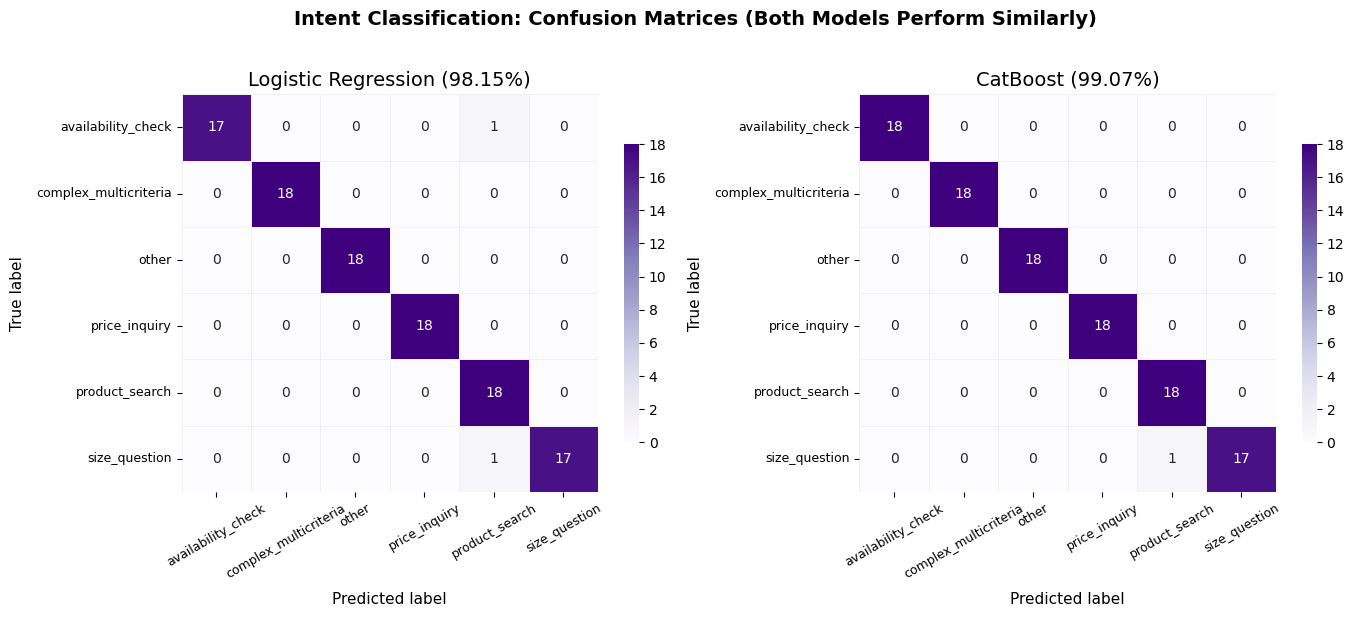

In [38]:
#fig1: confusion matrics graph
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix

#different class intentions 
CLASS_ORDER = [
    "availability_check",
    "complex_multicriteria",
    "other",
    "price_inquiry",
    "product_search",
    "size_question"]

#confusion matrix 
cm_lr  = confusion_matrix(y_test, y_pred,     labels=CLASS_ORDER)
cm_cat = confusion_matrix(y_test, y_pred_cat, labels=CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("white")

for ax, cm, title in zip(
    axes,
    [cm_lr, cm_cat],
    ["Logistic Regression (98.15%)", "CatBoost (99.07%)"],
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Purples",
        xticklabels=CLASS_ORDER,
        yticklabels=CLASS_ORDER,
        linewidths=0.5,
        linecolor="#f0f0f0",
        cbar_kws={"shrink": 0.75},
        ax=ax,
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted label", fontsize=11, labelpad=8)
    ax.set_ylabel("True label", fontsize=11, labelpad=8)
    ax.tick_params(axis="x", labelsize=9, rotation=30)
    ax.tick_params(axis="y", labelsize=9, rotation=0)

fig.suptitle(
    "Intent Classification: Confusion Matrices (Both Models Perform Similarly)", 
    fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()

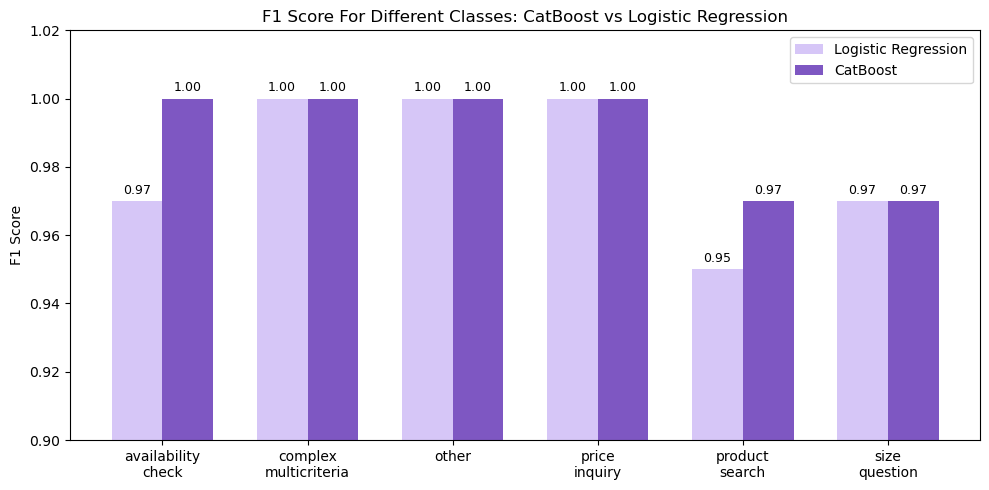

In [67]:
#fig2: F1 score graph
classes = ['availability\ncheck', 'complex\nmulticriteria', 
           'other', 'price\ninquiry', 'product\nsearch', 
           'size\nquestion']

lr_f1 = [0.97, 1.00, 1.00, 1.00, 0.95, 0.97]
cat_f1 = [1.00, 1.00, 1.00, 1.00, 0.97, 0.97]

x = np.arange(len(classes))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, lr_f1, width,
               label='Logistic Regression',
               color='#d6c6f7')   # light purple

bars2 = ax.bar(x + width/2, cat_f1, width,
               label='CatBoost',
               color='#7e57c2')   # deeper purple

ax.set_ylim(0.90, 1.02)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score For Different Classes: CatBoost vs Logistic Regression')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.bar_label(bars1, padding=3, fmt='%.2f', fontsize=9)
ax.bar_label(bars2, padding=3, fmt='%.2f', fontsize=9)
plt.tight_layout()
plt.savefig('f1.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

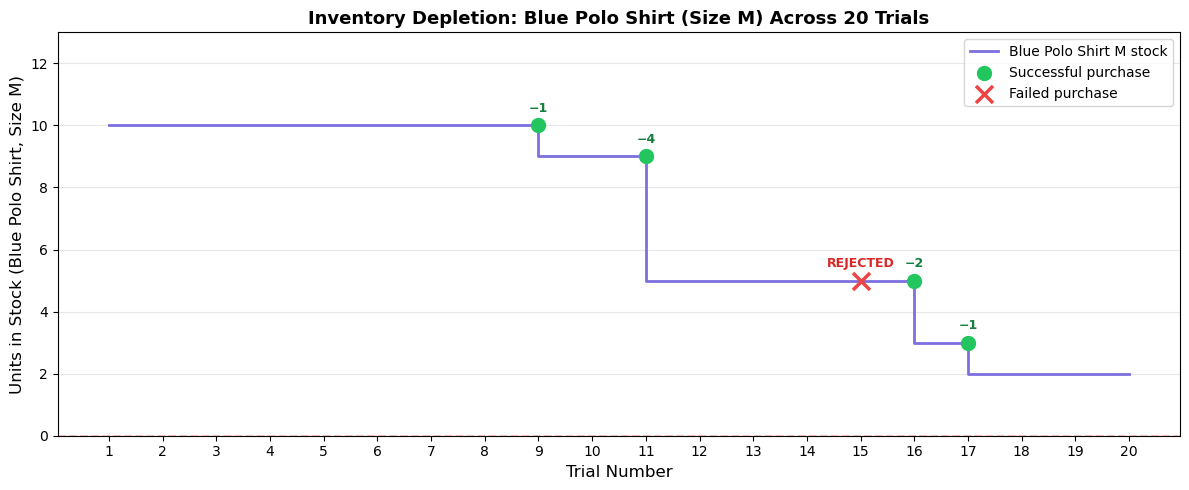

In [68]:
#fig3: inventory depletion graph 

# Filter only polo shirt M purchases from trial_df
polo_mask = trial_df['query'].str.contains('polo shirt', case=False, na=False) & \
            (trial_df['mode'] == 'purchase')
polo_df = trial_df[polo_mask].copy()
polo_df['outcome'] = polo_df.apply(
    lambda r: 'FAILED' if r['stock_after'] == r['stock_before'] 
    else 'SUCCESS', axis=1
)

all_trials = list(range(1, 21))
stock_line = []
current = 10
for t in all_trials:
    match = polo_df[polo_df['trial_num'] == t]
    if not match.empty and match.iloc[0]['outcome'] == 'SUCCESS':
        current = int(match.iloc[0]['stock_after'])
    stock_line.append(current)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(all_trials, stock_line, color='#7c6fe0', linewidth=2,
        drawstyle='steps-post', label='Blue Polo Shirt M stock')

success = polo_df[polo_df['outcome'] == 'SUCCESS']
failed = polo_df[polo_df['outcome'] == 'FAILED']

ax.scatter(success['trial_num'], success['stock_before'],
           color='#22c55e', s=100, zorder=5, label='Successful purchase')
ax.scatter(failed['trial_num'], failed['stock_before'],
           color='#ef4444', s=150, zorder=5,
           marker='x', linewidths=2.5, label='Failed purchase')

for _, row in polo_df.iterrows():
    diff = int(row['stock_before'] - row['stock_after'])
    label = f'−{diff}' if row['outcome'] == 'SUCCESS' else 'REJECTED'
    color = '#15803d' if row['outcome'] == 'SUCCESS' else '#dc2626'
    ax.annotate(label, (row['trial_num'], row['stock_before']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Trial Number', fontsize=12)
ax.set_ylabel('Units in Stock (Blue Polo Shirt, Size M)', fontsize=12)
ax.set_title('Inventory Depletion: Blue Polo Shirt (Size M) Across 20 Trials',
             fontsize=13, fontweight='bold')
ax.set_xticks(all_trials)
ax.set_ylim(0, 13)
ax.axhline(y=0, color='#ef4444', linestyle='--', alpha=0.3)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('inventory_depletion.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

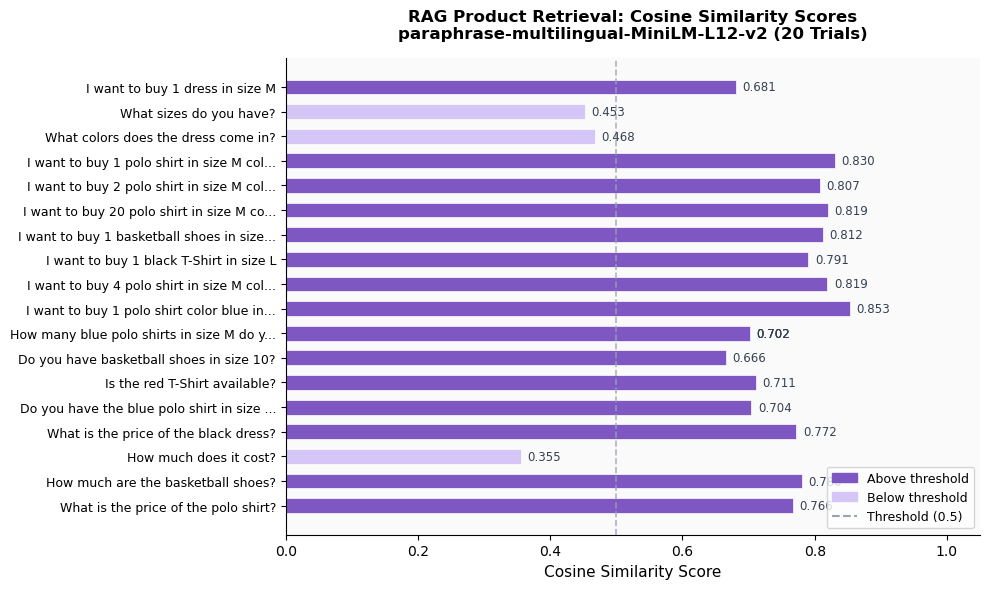

In [69]:
#fig4: consine similarity score

short_q = [q[:40]+'...' if len(q)>40 else q 
           for q in queries_used]
bar_colors = ['#7e57c2' if s >= 0.5 else '#d6c6f7' 
              for s in scores]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

bars = ax.barh(short_q, scores,
               color=bar_colors,
               height=0.6,
               edgecolor='white',
               linewidth=0.5)

ax.axvline(x=0.5, color='#9ca3af',
           linestyle='--', linewidth=1.2,
           alpha=0.8)

ax.set_xlabel('Cosine Similarity Score', fontsize=11)
ax.set_title(
    'RAG Product Retrieval: Cosine Similarity Scores\n'
    'paraphrase-multilingual-MiniLM-L12-v2 (20 Trials)',
    fontsize=12, fontweight='bold', pad=14)
ax.set_xlim(0, 1.05)
ax.set_facecolor('#fafafa')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=10)

for bar, score in zip(bars, scores):
    ax.text(score + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center',
            fontsize=8.5, color='#374151')

import matplotlib.patches as mpatches
above = mpatches.Patch(color='#7e57c2', 
                       label='Above threshold')
below = mpatches.Patch(color='#d6c6f7', 
                       label='Below threshold')
ax.legend(handles=[above, below,
    plt.Line2D([0],[0], color='#9ca3af',
               linestyle='--', 
               label='Threshold (0.5)')],
    fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('rag_retrieval.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()